In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
train_data = np.load('quickdraw_train.npz')

X_raw = train_data['x_train']
Y_raw = train_data['y_train']
class_names = train_data['class_names']

print(f"Dataset loaded successfully!")
print(f"Classes: {class_names}")
print(f"Raw data shape: {X_raw.shape}")

Dataset loaded successfully!
Classes: ['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']
Raw data shape: (60000, 784)


In [ ]:
X_normalized = X_raw.astype('float32') / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    X_normalized, Y_raw, test_size=0.2, random_state=42, stratify=Y_raw
)

print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_val)}")

Training set size: 48000
Validation set size: 12000


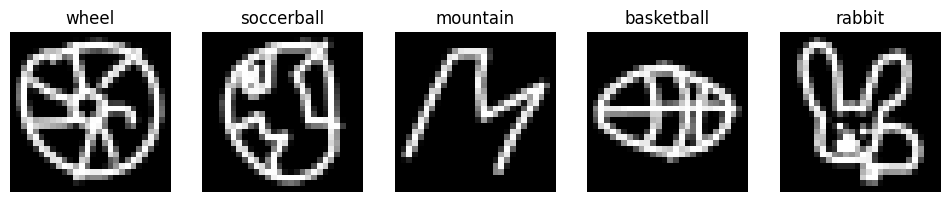

In [ ]:
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=2048, num_classes=15):
        super(PancakeMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)

        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = PancakeMLP().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 1,638,415


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.Tensor(x_train), torch.LongTensor(y_train)),
    batch_size=128, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.Tensor(x_val), torch.LongTensor(y_val)),
    batch_size=128, shuffle=False
)

In [ ]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=40):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        start_time = time.time()

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct_train / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        v_loss = val_loss / len(val_loader.dataset)
        v_acc = 100 * correct_val / total_val

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        end_time = time.time()
        print(f"Epoch [{epoch+1}/{epochs}] - Train Acc: {epoch_acc:.2f}% | Val Acc: {v_acc:.2f}% - {end_time-start_time:.1f}s")

    return history

pancake_history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20)

Epoch [1/20] - Train Acc: 63.11% | Val Acc: 69.38% - 1.6s
Epoch [2/20] - Train Acc: 73.26% | Val Acc: 73.27% - 1.1s
Epoch [3/20] - Train Acc: 78.20% | Val Acc: 74.90% - 1.1s
Epoch [4/20] - Train Acc: 81.85% | Val Acc: 75.62% - 1.4s
Epoch [5/20] - Train Acc: 84.84% | Val Acc: 75.83% - 1.4s
Epoch [6/20] - Train Acc: 87.67% | Val Acc: 76.08% - 1.3s
Epoch [7/20] - Train Acc: 90.35% | Val Acc: 76.09% - 1.1s
Epoch [8/20] - Train Acc: 92.95% | Val Acc: 75.64% - 1.1s
Epoch [9/20] - Train Acc: 95.11% | Val Acc: 75.50% - 1.1s
Epoch [10/20] - Train Acc: 96.74% | Val Acc: 76.31% - 1.1s
Epoch [11/20] - Train Acc: 98.03% | Val Acc: 75.70% - 1.1s
Epoch [12/20] - Train Acc: 98.59% | Val Acc: 75.81% - 1.1s
Epoch [13/20] - Train Acc: 99.38% | Val Acc: 75.64% - 1.1s
Epoch [14/20] - Train Acc: 99.53% | Val Acc: 75.22% - 1.1s
Epoch [15/20] - Train Acc: 99.56% | Val Acc: 75.62% - 1.2s
Epoch [16/20] - Train Acc: 99.69% | Val Acc: 75.66% - 1.4s
Epoch [17/20] - Train Acc: 97.16% | Val Acc: 74.28% - 1.4s
Epoch 

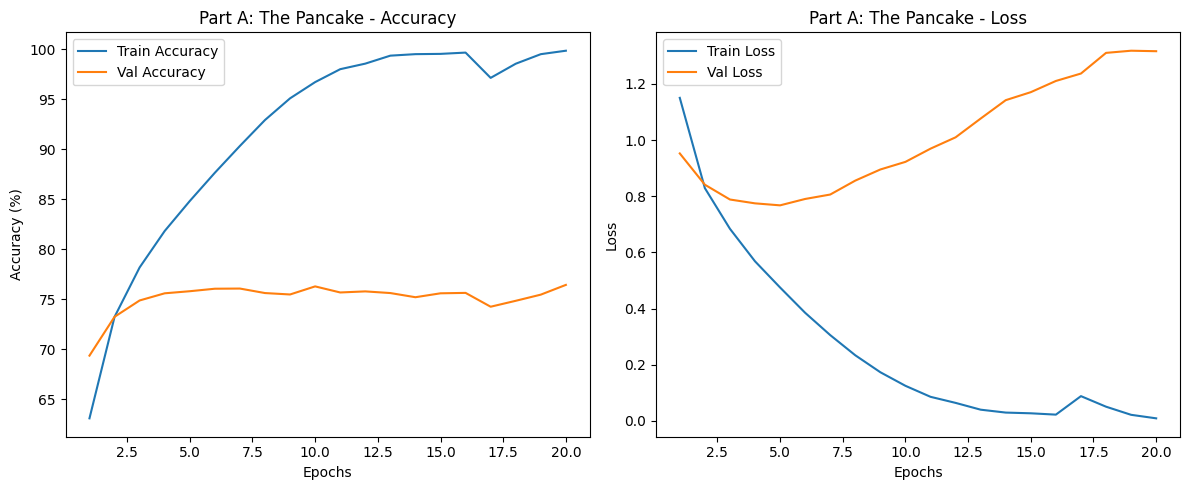

In [ ]:
def plot_history(history, title="Model Training History"):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(pancake_history, title="Part A: The Pancake")

In [ ]:
class TowerMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=15):
        super(TowerMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)

        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)

        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.bn4 = nn.BatchNorm1d(hidden_size)

        self.fc5 = nn.Linear(hidden_size, hidden_size)
        self.bn5 = nn.BatchNorm1d(hidden_size)

        self.out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = F.relu(self.bn5(self.fc5(x)))
        return self.out(x)

tower_model = TowerMLP().to(device)
tower_params = sum(p.numel() for p in tower_model.parameters())
print(f"Tower Total Parameters: {tower_params:,}")

Tower Total Parameters: 470,543


In [ ]:
tower_model = TowerMLP().to(device)

optimizer_tower = optim.Adam(tower_model.parameters(), lr=0.001)

tower_history = train_model(tower_model, train_loader, val_loader, criterion, optimizer_tower, epochs=20)

Epoch [1/20] - Train Acc: 65.89% | Val Acc: 70.03% - 1.7s
Epoch [2/20] - Train Acc: 74.22% | Val Acc: 73.67% - 1.6s
Epoch [3/20] - Train Acc: 78.04% | Val Acc: 75.23% - 1.7s
Epoch [4/20] - Train Acc: 80.55% | Val Acc: 76.12% - 1.6s
Epoch [5/20] - Train Acc: 82.48% | Val Acc: 75.94% - 2.1s
Epoch [6/20] - Train Acc: 84.25% | Val Acc: 76.91% - 2.1s
Epoch [7/20] - Train Acc: 86.17% | Val Acc: 76.42% - 1.6s
Epoch [8/20] - Train Acc: 87.49% | Val Acc: 76.78% - 1.6s
Epoch [9/20] - Train Acc: 88.79% | Val Acc: 76.44% - 1.6s
Epoch [10/20] - Train Acc: 90.15% | Val Acc: 76.27% - 1.6s
Epoch [11/20] - Train Acc: 90.99% | Val Acc: 76.12% - 1.6s
Epoch [12/20] - Train Acc: 92.17% | Val Acc: 76.31% - 1.6s
Epoch [13/20] - Train Acc: 92.92% | Val Acc: 76.00% - 2.2s
Epoch [14/20] - Train Acc: 93.39% | Val Acc: 75.31% - 2.0s
Epoch [15/20] - Train Acc: 94.01% | Val Acc: 75.67% - 1.6s
Epoch [16/20] - Train Acc: 94.50% | Val Acc: 75.94% - 1.6s
Epoch [17/20] - Train Acc: 95.08% | Val Acc: 75.77% - 1.6s
Epoch 

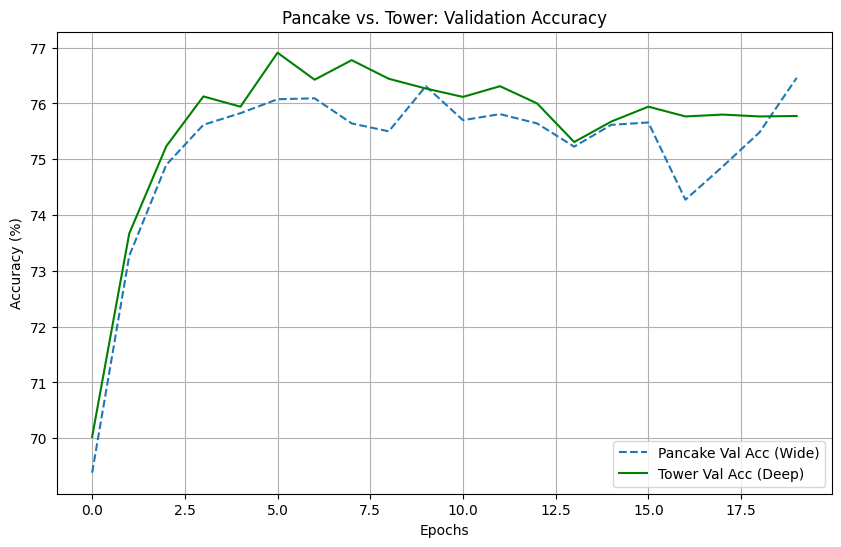

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(pancake_history['val_acc'], label='Pancake Val Acc (Wide)', linestyle='--')
plt.plot(tower_history['val_acc'], label='Tower Val Acc (Deep)', color='green')
plt.title('Pancake vs. Tower: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class QuickDrawDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            img = x.view(1, 28, 28)
            img = self.transform(img)
            x = img.view(784)
        return x, self.y[idx]

train_loader = DataLoader(
    QuickDrawDataset(x_train, y_train, augment=True),
    batch_size=128, shuffle=True
)
val_loader = DataLoader(
    QuickDrawDataset(x_val, y_val, augment=False),
    batch_size=128, shuffle=False
)

In [ ]:
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x.view(-1, 784))

model_champ = ChampionMLP().to(device)
champ_params = sum(p.numel() for p in model_champ.parameters())
print(f"Champion Parameters: {champ_params:,}")

Champion Parameters: 569,871


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_champ = optim.AdamW(model_champ.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_champ, T_max=40, eta_min=1e-6)

In [ ]:
def train_model_with_scheduler(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=40):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                v_loss = criterion(outputs, labels)
                val_loss += v_loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['train_acc'].append(100 * correct_train / total_train)
        history['val_loss'].append(val_loss / len(val_loader.dataset))
        history['val_acc'].append(100 * correct_val / total_val)
        history['lr'].append(current_lr)

        print(f"Epoch [{epoch+1}/{epochs}] - Val Acc: {history['val_acc'][-1]:.2f}% | LR: {current_lr:.6f}")

    return history

champ_history = train_model_with_scheduler(model_champ, train_loader, val_loader, criterion, optimizer_champ, scheduler, epochs=40)

Epoch [1/40] - Val Acc: 69.90% | LR: 0.001000
Epoch [2/40] - Val Acc: 72.84% | LR: 0.000998
Epoch [3/40] - Val Acc: 74.36% | LR: 0.000994
Epoch [4/40] - Val Acc: 75.99% | LR: 0.000986
Epoch [5/40] - Val Acc: 76.22% | LR: 0.000976
Epoch [6/40] - Val Acc: 77.59% | LR: 0.000962
Epoch [7/40] - Val Acc: 78.39% | LR: 0.000946
Epoch [8/40] - Val Acc: 78.47% | LR: 0.000926
Epoch [9/40] - Val Acc: 79.72% | LR: 0.000905
Epoch [10/40] - Val Acc: 80.19% | LR: 0.000880
Epoch [11/40] - Val Acc: 80.05% | LR: 0.000854
Epoch [12/40] - Val Acc: 80.68% | LR: 0.000825
Epoch [13/40] - Val Acc: 80.75% | LR: 0.000794
Epoch [14/40] - Val Acc: 80.76% | LR: 0.000761
Epoch [15/40] - Val Acc: 81.53% | LR: 0.000727
Epoch [16/40] - Val Acc: 81.78% | LR: 0.000692
Epoch [17/40] - Val Acc: 82.16% | LR: 0.000655
Epoch [18/40] - Val Acc: 82.00% | LR: 0.000617
Epoch [19/40] - Val Acc: 82.35% | LR: 0.000579
Epoch [20/40] - Val Acc: 82.80% | LR: 0.000540
Epoch [21/40] - Val Acc: 82.64% | LR: 0.000500
Epoch [22/40] - Val Ac

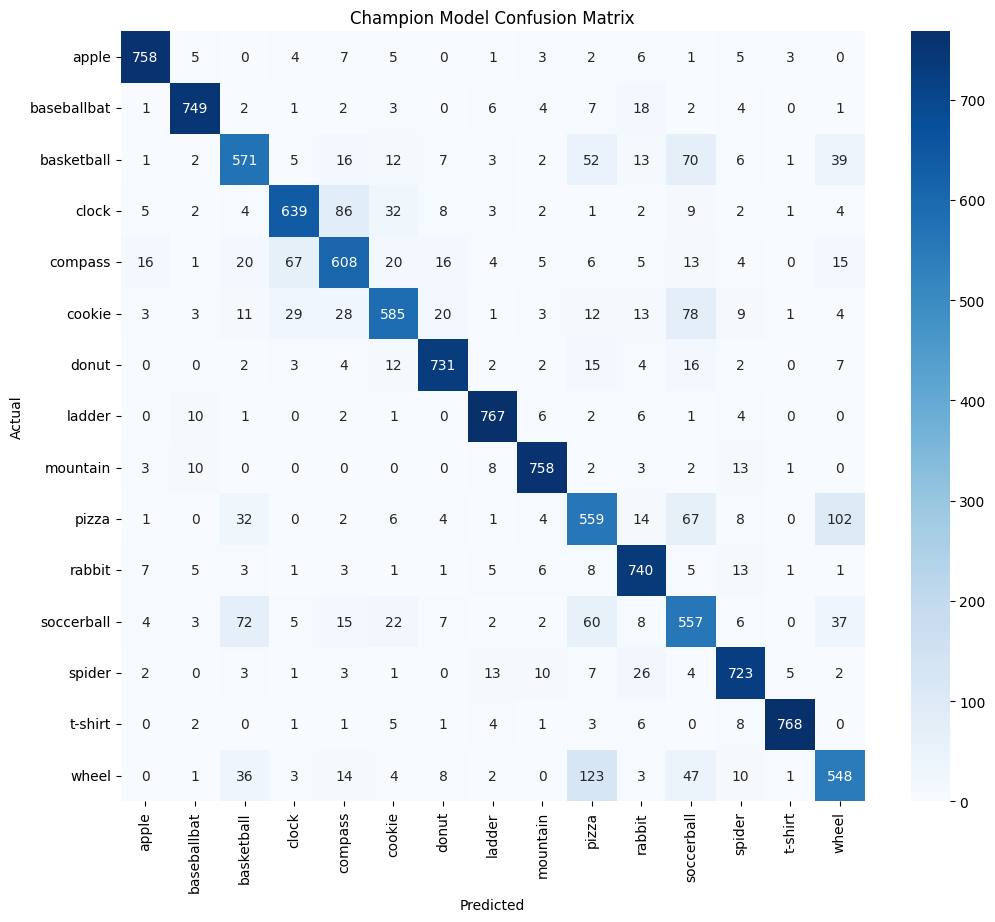

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Champion Model Confusion Matrix')
    plt.show()

plot_confusion_matrix(model_champ, val_loader)

In [ ]:
test_data = np.load('quickdraw_test.npz')
X_test = test_data['test_images'].astype('float32') / 255.0
X_test_tensor = torch.FloatTensor(X_test).to(device)

model_champ.eval()
with torch.no_grad():
    outputs = model_champ(X_test_tensor)
    _, predictions = torch.max(outputs, 1)

preds = predictions.cpu().numpy()
print(f"Total predictions: {len(preds)}")
print(f"Prediction range: {preds.min()} - {preds.max()}")

pred_string = ','.join(map(str, preds))
print(f"\nFirst 50 values: {pred_string[:100]}...")
print(f"\nFull CSV (copy this into the submission box):")
print(pred_string)

Total predictions: 15000
Prediction range: 0 - 14

First 50 values: 6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,9,5,8,2,12,...

Full CSV (copy this into the submission box):
6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,14,11,1,12,13,5,9,5,8,2,12,8,0,2,13,1,6,9,10,1,5,11,0,11,2,11,11,6,10,11,9,6,7,2,0,12,11,12,3,11,4,6,3,14,13,6,5,6,2,11,10,13,6,4,12,0,0,2,14,11,0,7,1,11,5,6,3,12,9,10,14,12,1,4,5,9,7,4,11,11,9,1,1,13,12,2,1,7,9,0,4,7,14,2,13,13,7,14,3,4,5,6,0,8,9,11,11,12,1,13,10,11,1,14,1,12,7,11,3,0,4,14,1,12,6,8,0,4,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,6,7,11,2,13,10,3,12,3,8,6,11,1,9,9,8,6,0,4,1,5,5,2,5,14,10,1,13,1,1,10,5,7,14,5,1,9,6,2,6,3,8,1,1,4,7,4,9,11,13,14,4,0,11,6,4,11,1,3,10,0,11,4,9,11,4,12,4,9,5,0,6,7,6,5,7,1,13,5,1,9,0,4,13,0,7,4,6,4,12,12,3,7,13,11,11,3,10,7,12,8,6,6,1,7,12,8,0,3,14,4,12,6,6,6,2,0,9,12,9,6,3,8,5,12,3,0,6,11,11,7,13,8,12,13,9,1,5,3,9,10,14,13,0,9,12,11,7,9,3,10,11,12,13,12,6